In [ ]:
import os, json
os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_credentials = {
    "username": "your kaggle username",
    "key": "your kaggle key"
}
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d abdallahalidev/plantvillage-dataset
import zipfile
with zipfile.ZipFile("plantvillage-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("plantvillage")
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:11<00:00, 186MB/s]

Dataset ready!


In [ ]:
from google.colab import files
import os

os.makedirs("model", exist_ok=True)
print("Select best_model.pth from your laptop...")
uploaded = files.upload()

import shutil
shutil.copy("best_model.pth", "model/best_model.pth")
print("Model ready at model/best_model.pth!")

Select best_model.pth from your laptop...


Saving best_model.pth to best_model.pth
Model ready at model/best_model.pth!


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# We need class names in the exact same order as training
base_path = "plantvillage/plantvillage dataset/color"
dataset = datasets.ImageFolder(base_path)
class_names = dataset.classes

print(f"Total classes: {len(class_names)}")
print(f"First 5: {class_names[:5]}")
print(f"Last 5:  {class_names[-5:]}")

Total classes: 38
First 5: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
Last 5:  ['Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [ ]:
model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(in_features=1280, out_features=38)
model.load_state_dict(torch.load("model/best_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
def predict(image_path, model, class_names, device):
    """
    Takes a single image path.
    Returns disease name + confidence %.
    """

    # Step 1 — Load and preprocess image
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)  # [1, 3, 224, 224]

    # Step 2 — Forward pass
    with torch.no_grad():
        outputs = model(img_tensor)              # raw scores for 38 classes
        probs   = torch.softmax(outputs, dim=1)  # convert to probabilities 0-1
        confidence, pred_idx = probs.max(1)      # highest probability + its index

    # Step 3 — Decode result
    pred_idx      = pred_idx.item()
    confidence    = confidence.item() * 100

    raw_name      = class_names[pred_idx]        # e.g. "Apple___Apple_scab"
    plant         = raw_name.split("___")[0].replace("_", " ")
    disease       = raw_name.split("___")[1].replace("_", " ")

    return {
        "plant":      plant,
        "disease":    disease,
        "confidence": round(confidence, 2),
        "class_idx":  pred_idx,
        "raw_name":   raw_name
    }

print("predict() function ready!")

predict() function ready!


In [ ]:
import random

# Pick 10 random images from the dataset
random.seed(99)
sample_indices = random.sample(range(len(dataset)), 10)

print(f"{'#':<3} {'True Label':<40} {'Predicted':<40} {'Confidence':>10} {'Match'}")
print("-" * 100)

correct = 0
for i, idx in enumerate(sample_indices):
    img_path, true_idx = dataset.samples[idx]
    true_name = class_names[true_idx].split("___")[1].replace("_", " ")

    result = predict(img_path, model, class_names, device)

    match = "✓" if result["disease"] == true_name else "✗"
    if result["disease"] == true_name:
        correct += 1

    print(f"{i+1:<3} {true_name:<40} {result['disease']:<40} {result['confidence']:>9.2f}% {match}")

print("-" * 100)
print(f"Score: {correct}/10 correct")

#   True Label                               Predicted                                Confidence Match
----------------------------------------------------------------------------------------------------
1   Late blight                              Late blight                                  99.99% ✓
2   healthy                                  healthy                                     100.00% ✓
3   Leaf blight (Isariopsis Leaf Spot)       Leaf blight (Isariopsis Leaf Spot)          100.00% ✓
4   Late blight                              Late blight                                  99.99% ✓
5   Esca (Black Measles)                     Esca (Black Measles)                         99.98% ✓
6   Haunglongbing (Citrus greening)          Haunglongbing (Citrus greening)             100.00% ✓
7   Haunglongbing (Citrus greening)          Haunglongbing (Citrus greening)             100.00% ✓
8   Northern Leaf Blight                     Northern Leaf Blight                         99.93% ✓
9   

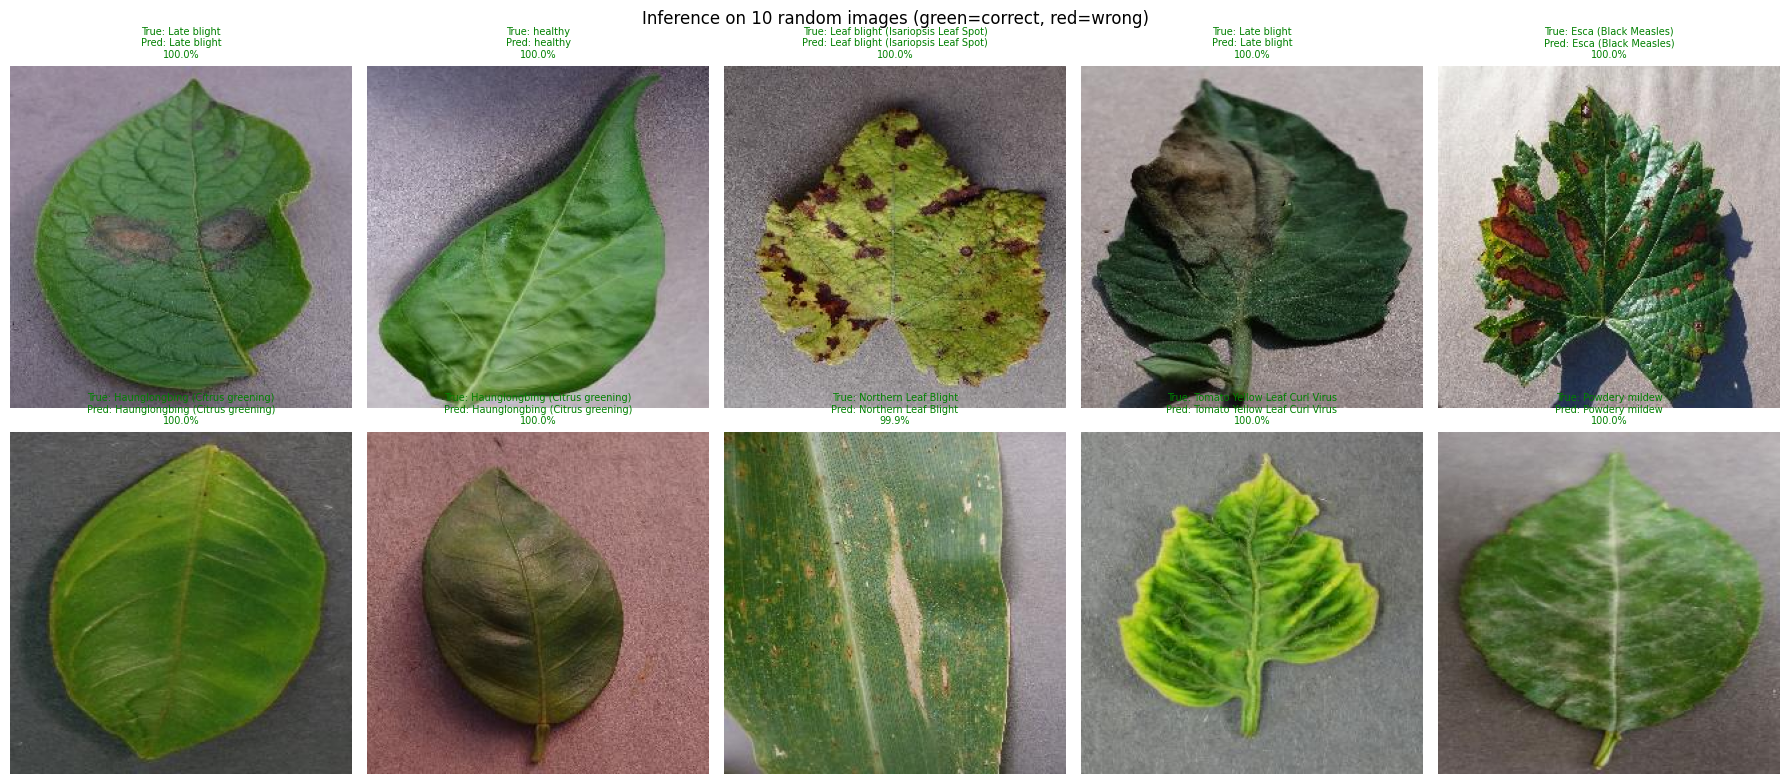

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img_path, true_idx = dataset.samples[idx]
    true_name = class_names[true_idx].split("___")[1].replace("_", " ")

    result = predict(img_path, model, class_names, device)

    img = Image.open(img_path).convert("RGB")
    axes[i].imshow(img)

    match = result["disease"] == true_name
    color = "green" if match else "red"

    axes[i].set_title(
        f"True: {true_name}\nPred: {result['disease']}\n{result['confidence']:.1f}%",
        fontsize=7,
        color=color
    )
    axes[i].axis("off")

plt.suptitle("Inference on 10 random images (green=correct, red=wrong)", fontsize=12)
plt.tight_layout()
plt.savefig("inference_results.png", dpi=150)
plt.show()

In [ ]:
inference_code = '''
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = None  # loaded at startup

def load_model(model_path, class_names):
    global CLASS_NAMES
    CLASS_NAMES = class_names

    model = efficientnet_b0(weights=None)
    model.classifier[1] = nn.Linear(in_features=1280, out_features=len(class_names))
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model

def predict(image_path, model):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs   = torch.softmax(outputs, dim=1)
        confidence, pred_idx = probs.max(1)

    pred_idx   = pred_idx.item()
    confidence = confidence.item() * 100
    raw_name   = CLASS_NAMES[pred_idx]
    plant      = raw_name.split("___")[0].replace("_", " ")
    disease    = raw_name.split("___")[1].replace("_", " ")

    return {
        "plant":      plant,
        "disease":    disease,
        "confidence": round(confidence, 2),
        "raw_name":   raw_name
    }
'''

with open("inference.py", "w") as f:
    f.write(inference_code)

# Download to laptop
from google.colab import files
files.download("inference.py")
print("inference.py saved and downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

inference.py saved and downloaded!
